# Progressive Project — Deliverable 5
## Medicare Inpatient Hospitals Analysis Notebook
**Dataset:** Medicare Inpatient Hospitals - by Provider and Service (FY 2024)  
**Source:** Centers for Medicare & Medicaid Services | data.cms.gov  
**Environment:** Google Colab + BigQuery  

This notebook connects to a BigQuery dataset loaded from the CMS Medicare Inpatient Hospitals (FY 2024) CSV file, performs data cleaning, exploratory analysis, and visualization, and derives three business insights from the data.

---
## Section 1: Environment Setup & Authentication
We begin by installing and importing all required libraries, then authenticating with Google Cloud so that this notebook can query BigQuery.

In [ ]:
# Install the BigQuery client library (pre-installed in Colab, but included for clarity)
!pip install google-cloud-bigquery pandas-gbq --quiet

In [ ]:
# Authenticate with Google Cloud
from google.colab import auth
auth.authenticate_user()
print('Authentication successful.')

Authentication successful.


In [ ]:
# Import all required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from google.cloud import bigquery

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

# Set global plot style
sns.set_theme(style='whitegrid', palette='Blues_d')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'sans-serif'

print('All libraries imported successfully.')

All libraries imported successfully.


In [ ]:

PROJECT_ID = 'cis5630-klugh'
DATASET    = 'Medicare_IP_Hospitals'
TABLE      = 'MC_Data'
TABLE_REF  = f'{PROJECT_ID}.{DATASET}.{TABLE}'


client = bigquery.Client(project=PROJECT_ID)
print(f'BigQuery client initialized. Target table: {TABLE_REF}')

BigQuery client initialized. Target table: cis5630-klugh.Medicare_IP_Hospitals.MC_Data


---
## Section 2: Data Retrieval from BigQuery
We execute three SQL queries via Python to pull the data we need for analysis:
1. **Full dataset sample** - retrieve all columns for initial inspection
2. **State-level aggregation** - average charges and payments grouped by state
3. **Top DRG procedures** - highest-volume procedures nationally with payment statistics

In [ ]:
# Query 1: Full dataset retrieval (all columns, all rows)
query_full = f'''
SELECT
  Rndrng_Prvdr_CCN,
  Rndrng_Prvdr_Org_Name,
  Rndrng_Prvdr_City,
  Rndrng_Prvdr_State_Abrvtn  AS State,
  Rndrng_Prvdr_RUCA,
  Rndrng_Prvdr_RUCA_Desc,
  DRG_Cd,
  DRG_Desc,
  Tot_Dschrgs,
  Avg_Submtd_Cvrd_Chrg,
  Avg_Tot_Pymt_Amt,
  Avg_Mdcr_Pymt_Amt
FROM `{TABLE_REF}`
'''

df = client.query(query_full).to_dataframe()
print(f'Rows retrieved: {len(df):,}')
print(f'Columns: {list(df.columns)}')
df.head()

Rows retrieved: 145,879
Columns: ['Rndrng_Prvdr_CCN', 'Rndrng_Prvdr_Org_Name', 'Rndrng_Prvdr_City', 'State', 'Rndrng_Prvdr_RUCA', 'Rndrng_Prvdr_RUCA_Desc', 'DRG_Cd', 'DRG_Desc', 'Tot_Dschrgs', 'Avg_Submtd_Cvrd_Chrg', 'Avg_Tot_Pymt_Amt', 'Avg_Mdcr_Pymt_Amt']


,Rndrng_Prvdr_CCN,Rndrng_Prvdr_Org_Name,Rndrng_Prvdr_City,State,Rndrng_Prvdr_RUCA,Rndrng_Prvdr_RUCA_Desc,DRG_Cd,DRG_Desc,Tot_Dschrgs,Avg_Submtd_Cvrd_Chrg,Avg_Tot_Pymt_Amt,Avg_Mdcr_Pymt_Amt
0,10001,Southeast Health Medical Center,Dothan,AL,2.0,Metropolitan area high commuting: primary flow...,3,ECMO OR TRACHEOSTOMY WITH MV >96 HOURS OR PRIN...,11,738478.636360,103236.272730,91218.181818
1,10001,Southeast Health Medical Center,Dothan,AL,2.0,Metropolitan area high commuting: primary flow...,23,CRANIOTOMY WITH MAJOR DEVICE IMPLANT OR ACUTE ...,23,173562.086960,40220.217391,37634.565217
2,10001,Southeast Health Medical Center,Dothan,AL,2.0,Metropolitan area high commuting: primary flow...,24,CRANIOTOMY WITH MAJOR DEVICE IMPLANT OR ACUTE ...,13,95613.307692,27305.461538,25644.307692
3,10001,Southeast Health Medical Center,Dothan,AL,2.0,Metropolitan area high commuting: primary flow...,25,CRANIOTOMY AND ENDOVASCULAR INTRACRANIAL PROCE...,22,182831.409090,31420.954545,23270.863636
4,10001,Southeast Health Medical Center,Dothan,AL,2.0,Metropolitan area high commuting: primary flow...,38,EXTRACRANIAL PROCEDURES WITH CC,27,111318.555560,12183.925926,10532.222222


In [ ]:
# Query 2: State-level aggregation
query_state = f'''
SELECT
  Rndrng_Prvdr_State_Abrvtn              AS State,
  COUNT(DISTINCT Rndrng_Prvdr_CCN)       AS Hospital_Count,
  SUM(Tot_Dschrgs)                       AS Total_Discharges,
  ROUND(AVG(Avg_Submtd_Cvrd_Chrg), 2)   AS Avg_Billed_Charge,
  ROUND(AVG(Avg_Mdcr_Pymt_Amt), 2)      AS Avg_Medicare_Payment,
  ROUND(AVG(Avg_Submtd_Cvrd_Chrg)
        - AVG(Avg_Mdcr_Pymt_Amt), 2)    AS Avg_Charge_Gap
FROM `{TABLE_REF}`
GROUP BY State
ORDER BY Avg_Billed_Charge DESC
'''

df_state = client.query(query_state).to_dataframe()
print(f'States returned: {len(df_state)}')
df_state.head(10)

States returned: 51


,State,Hospital_Count,Total_Discharges,Avg_Billed_Charge,Avg_Medicare_Payment,Avg_Charge_Gap
0,NV,21,43206,171924.94,15909.77,156015.16
1,CA,272,462315,156452.26,21712.77,134739.49
2,DC,6,16270,147237.41,25460.77,121776.64
3,CO,47,44567,145926.33,16413.58,129512.75
4,AK,8,9804,136114.77,20495.61,115619.15
5,NJ,61,176887,125963.15,15976.91,109986.24
6,TX,241,334970,124874.64,15248.25,109626.39
7,FL,165,444244,117305.60,13462.69,103842.91
8,NY,125,328890,115149.25,20216.16,94933.10
9,AZ,60,96271,105099.42,15678.36,89421.06


In [ ]:
# Query 3: Top 20 DRGs by national discharge volume
query_drg = f'''
SELECT
  DRG_Cd,
  DRG_Desc,
  SUM(Tot_Dschrgs)                      AS Total_Discharges,
  COUNT(DISTINCT Rndrng_Prvdr_CCN)      AS Hospital_Count,
  ROUND(AVG(Avg_Submtd_Cvrd_Chrg), 2)  AS Avg_Billed_Charge,
  ROUND(AVG(Avg_Mdcr_Pymt_Amt), 2)     AS Avg_Medicare_Payment,
  ROUND(AVG(Avg_Submtd_Cvrd_Chrg)
        / NULLIF(AVG(Avg_Mdcr_Pymt_Amt), 0), 2) AS Charge_To_Payment_Ratio
FROM `{TABLE_REF}`
GROUP BY DRG_Cd, DRG_Desc
ORDER BY Total_Discharges DESC
LIMIT 20
'''

df_drg = client.query(query_drg).to_dataframe()
print(f'DRG rows returned: {len(df_drg)}')
df_drg.head()

DRG rows returned: 20


,DRG_Cd,DRG_Desc,Total_Discharges,Hospital_Count,Avg_Billed_Charge,Avg_Medicare_Payment,Charge_To_Payment_Ratio
0,871,SEPTICEMIA OR SEVERE SEPSIS WITHOUT MV >96 HOU...,577119,2661,78400.11,15305.05,5.12
1,291,HEART FAILURE AND SHOCK WITH MCC,304694,2587,52916.32,10153.07,5.21
2,177,RESPIRATORY INFECTIONS AND INFLAMMATIONS WITH MCC,141351,2332,67024.00,12692.16,5.28
3,193,SIMPLE PNEUMONIA AND PLEURISY WITH MCC,136649,2442,56184.17,10038.65,5.60
4,872,SEPTICEMIA OR SEVERE SEPSIS WITHOUT MV >96 HOU...,103998,2216,46925.22,7693.42,6.10


---
## Section 3: Data Cleaning
Before analysis, we perform two cleaning operations on the main dataframe:
1. **Handle missing values** - identify and drop or fill null records in key fields
2. **Derive a RUCA classification column** - convert the numeric RUCA code into a readable Urban/Suburban/Rural label for grouping

We also add a computed column for the charge-to-payment ratio, which will be used throughout the analysis.

In [ ]:
# Cleaning Operation 1: Inspect and handle nulls
print('Null counts per column before cleaning:')
print(df.isnull().sum())

# Drop rows where critical financial fields are null
rows_before = len(df)
df = df.dropna(subset=['Avg_Submtd_Cvrd_Chrg', 'Avg_Mdcr_Pymt_Amt', 'Tot_Dschrgs'])
rows_after = len(df)
print(f'\nRows removed due to null financial fields: {rows_before - rows_after:,}')
print(f'Rows remaining: {rows_after:,}')

# Fill null RUCA descriptions with 'Unknown'
df['Rndrng_Prvdr_RUCA_Desc'] = df['Rndrng_Prvdr_RUCA_Desc'].fillna('Unknown')
print('\nNull counts after cleaning:')
print(df.isnull().sum())

Null counts per column before cleaning:
Rndrng_Prvdr_CCN          0
Rndrng_Prvdr_Org_Name     0
Rndrng_Prvdr_City         0
State                     0
Rndrng_Prvdr_RUCA         0
Rndrng_Prvdr_RUCA_Desc    0
DRG_Cd                    0
DRG_Desc                  0
Tot_Dschrgs               0
Avg_Submtd_Cvrd_Chrg      0
Avg_Tot_Pymt_Amt          0
Avg_Mdcr_Pymt_Amt         0
dtype: int64

Rows removed due to null financial fields: 0
Rows remaining: 145,879

Null counts after cleaning:
Rndrng_Prvdr_CCN          0
Rndrng_Prvdr_Org_Name     0
Rndrng_Prvdr_City         0
State                     0
Rndrng_Prvdr_RUCA         0
Rndrng_Prvdr_RUCA_Desc    0
DRG_Cd                    0
DRG_Desc                  0
Tot_Dschrgs               0
Avg_Submtd_Cvrd_Chrg      0
Avg_Tot_Pymt_Amt          0
Avg_Mdcr_Pymt_Amt         0
dtype: int64


In [ ]:
# Cleaning Operation 2: Derive Urban/Rural classification from RUCA
def classify_ruca(ruca):
    try:
        val = float(ruca)
        if val <= 3:
            return 'Urban'
        elif val <= 6:
            return 'Suburban'
        else:
            return 'Rural'
    except (ValueError, TypeError):
        return 'Unknown'

df['Setting'] = df['Rndrng_Prvdr_RUCA'].apply(classify_ruca)
print('Setting distribution:')
print(df['Setting'].value_counts())

# Derive charge-to-payment ratio
df['Charge_To_Payment_Ratio'] = (
    df['Avg_Submtd_Cvrd_Chrg'] / df['Avg_Mdcr_Pymt_Amt'].replace(0, np.nan)
).round(2)

print('\nSample of derived columns:')
df[['Rndrng_Prvdr_Org_Name', 'State', 'Setting', 'Charge_To_Payment_Ratio']].head()

Setting distribution:
Setting
Urban       131744
Suburban     11426
Rural         2709
Name: count, dtype: int64

Sample of derived columns:


,Rndrng_Prvdr_Org_Name,State,Setting,Charge_To_Payment_Ratio
0,Southeast Health Medical Center,AL,Urban,8.10
1,Southeast Health Medical Center,AL,Urban,4.61
2,Southeast Health Medical Center,AL,Urban,3.73
3,Southeast Health Medical Center,AL,Urban,7.86
4,Southeast Health Medical Center,AL,Urban,10.57


---
## Section 4: Exploratory Analysis
We perform four summary and groupby operations to understand the structure and patterns in the data:
1. Overall descriptive statistics on financial fields
2. Average Medicare payment grouped by urban/rural setting
3. State-level charge-to-payment ratio analysis
4. Top 10 DRGs by average billed charge

In [ ]:
# EDA 1: Descriptive statistics on financial fields
print('=== Descriptive Statistics: Key Financial Fields ===')
financial_cols = ['Tot_Dschrgs', 'Avg_Submtd_Cvrd_Chrg', 'Avg_Mdcr_Pymt_Amt', 'Charge_To_Payment_Ratio']
df[financial_cols].describe().round(2)

=== Descriptive Statistics: Key Financial Fields ===


,Tot_Dschrgs,Avg_Submtd_Cvrd_Chrg,Avg_Mdcr_Pymt_Amt,Charge_To_Payment_Ratio
count,145879.0,145879.00,145879.00,145879.00
mean,33.95,96366.09,15782.65,6.48
std,50.57,129334.70,19662.87,3.70
min,11.0,2058.38,386.80,0.16
25%,14.0,36845.23,7078.13,4.11
50%,20.0,61619.59,10850.70,5.63
75%,35.0,110042.34,17252.62,7.85
max,3400.0,7196636.94,1436667.83,52.93


In [ ]:
# EDA 2: Average Medicare payment by Urban/Rural setting
print('=== Average Medicare Payment by Care Setting ===')
setting_summary = df.groupby('Setting').agg(
    Hospital_Records   = ('Rndrng_Prvdr_CCN', 'count'),
    Total_Discharges   = ('Tot_Dschrgs', 'sum'),
    Avg_Medicare_Pmt   = ('Avg_Mdcr_Pymt_Amt', 'mean'),
    Avg_Billed_Charge  = ('Avg_Submtd_Cvrd_Chrg', 'mean'),
    Avg_Charge_Ratio   = ('Charge_To_Payment_Ratio', 'mean')
).round(2)
print(setting_summary)

=== Average Medicare Payment by Care Setting ===
          Hospital_Records  Total_Discharges  Avg_Medicare_Pmt  \
Setting                                                          
Rural                 2709             73010          11645.10   
Suburban             11426            327098          11151.76   
Urban               131744           4552373          16269.36   

          Avg_Billed_Charge  Avg_Charge_Ratio  
Setting                                        
Rural              55283.87              4.85  
Suburban           51032.40              4.87  
Urban             101142.59              6.65  


In [ ]:
# EDA 3: Top 10 states by average charge-to-payment ratio
print('=== Top 10 States: Highest Average Charge-to-Payment Ratio ===')
state_ratio = df.groupby('State').agg(
    Avg_Charge_Ratio  = ('Charge_To_Payment_Ratio', 'mean'),
    Avg_Billed        = ('Avg_Submtd_Cvrd_Chrg', 'mean'),
    Avg_Medicare_Pmt  = ('Avg_Mdcr_Pymt_Amt', 'mean')
).round(2).sort_values('Avg_Charge_Ratio', ascending=False)
print(state_ratio.head(10))

=== Top 10 States: Highest Average Charge-to-Payment Ratio ===
       Avg_Charge_Ratio  Avg_Billed  Avg_Medicare_Pmt
State                                                
NV                11.40   171924.94          15909.77
CO                 9.34   145926.33          16413.58
FL                 9.27   117305.60          13462.69
NJ                 8.88   125963.15          15976.91
TX                 8.49   124874.64          15248.25
CA                 7.77   156452.26          21712.77
AL                 7.50    87115.75          12143.05
KS                 7.50    96347.51          13562.71
AZ                 7.36   105099.42          15678.36
AK                 7.21   136114.77          20495.61


In [ ]:
# EDA 4: Top 10 DRGs by average billed charge
print('=== Top 10 DRG Procedures by Average Billed Charge ===')
drg_summary = df.groupby(['DRG_Cd', 'DRG_Desc']).agg(
    Avg_Billed        = ('Avg_Submtd_Cvrd_Chrg', 'mean'),
    Avg_Medicare_Pmt  = ('Avg_Mdcr_Pymt_Amt', 'mean'),
    Total_Discharges  = ('Tot_Dschrgs', 'sum')
).round(2).sort_values('Avg_Billed', ascending=False)
print(drg_summary.head(10))

=== Top 10 DRG Procedures by Average Billed Charge ===
                                                           Avg_Billed  \
DRG_Cd DRG_Desc                                                         
18     CHIMERIC ANTIGEN RECEPTOR (CAR) T-CELL AND OTHE...  2276259.99   
1      HEART TRANSPLANT OR IMPLANT OF HEART ASSIST SYS...  1569030.88   
7      LUNG TRANSPLANT                                     1042550.67   
3      ECMO OR TRACHEOSTOMY WITH MV >96 HOURS OR PRINC...  1041535.85   
5      LIVER TRANSPLANT WITH MCC OR INTESTINAL TRANSPLANT   834474.31   
426    MULTIPLE LEVEL COMBINED ANTERIOR AND POSTERIOR ...   677446.77   
4      TRACHEOSTOMY WITH MV >96 HOURS OR PRINCIPAL DIA...   649944.77   
212    CONCOMITANT AORTIC AND MITRAL VALVE PROCEDURES       602318.52   
14     ALLOGENEIC BONE MARROW TRANSPLANT                    595813.32   
456    SPINAL FUSION EXCEPT CERVICAL WITH SPINAL CURVA...   534203.00   

                                                           Avg_Medic

---
## Section 5: Visualization
Two charts are produced below:
1. **Bar chart** - Top 15 states by average billed charge vs. average Medicare payment (side-by-side)
2. **Scatter plot** - Relationship between total discharges and average Medicare payment across the top 20 DRGs

Both charts are designed to surface patterns relevant to the business insights in Section 7.

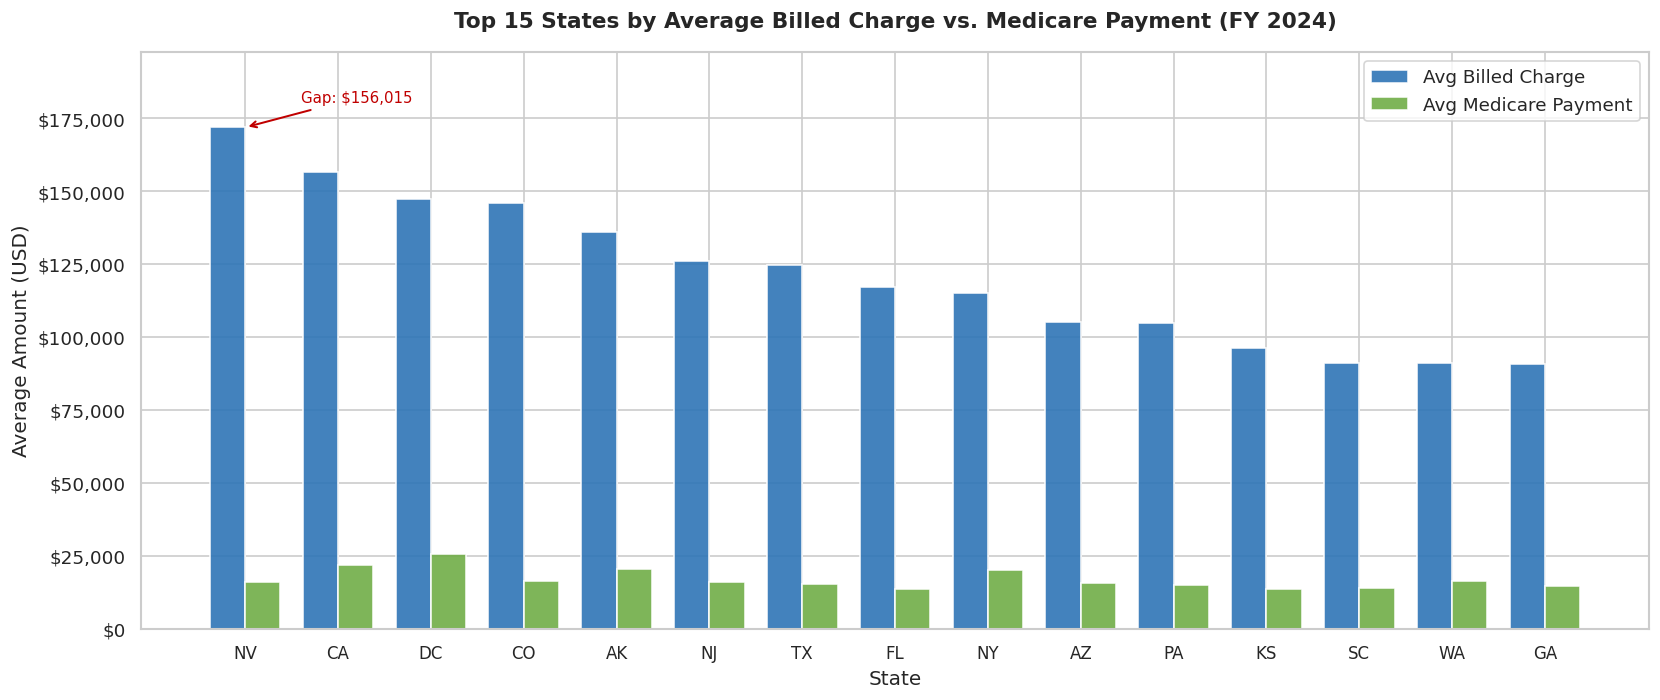

Chart 1 saved.


In [ ]:
# Chart 1: Top 15 states - Billed Charge vs. Medicare Payment
top15_states = df_state.head(15).copy()

x = np.arange(len(top15_states))
width = 0.38

fig, ax = plt.subplots(figsize=(14, 6))
bars1 = ax.bar(x - width/2, top15_states['Avg_Billed_Charge'],  width, label='Avg Billed Charge',    color='#2E75B6', alpha=0.9)
bars2 = ax.bar(x + width/2, top15_states['Avg_Medicare_Payment'], width, label='Avg Medicare Payment', color='#70AD47', alpha=0.9)

ax.set_xlabel('State', fontsize=12)
ax.set_ylabel('Average Amount (USD)', fontsize=12)
ax.set_title('Top 15 States by Average Billed Charge vs. Medicare Payment (FY 2024)',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xticks(x)
ax.set_xticklabels(top15_states['State'], rotation=0, fontsize=10)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'${v:,.0f}'))
ax.legend(fontsize=11)
ax.set_ylim(0, top15_states['Avg_Billed_Charge'].max() * 1.15)

# Annotate gap for top state
top = top15_states.iloc[0]
gap_val = top['Avg_Billed_Charge'] - top['Avg_Medicare_Payment']
ax.annotate(f"Gap: ${gap_val:,.0f}",
            xy=(0, top['Avg_Billed_Charge']),
            xytext=(0.6, top['Avg_Billed_Charge'] * 1.05),
            fontsize=9, color='#C00000',
            arrowprops=dict(arrowstyle='->', color='#C00000', lw=1.2))

plt.tight_layout()
plt.savefig('chart1_state_charges.png', bbox_inches='tight')
plt.show()
print('Chart 1 saved.')

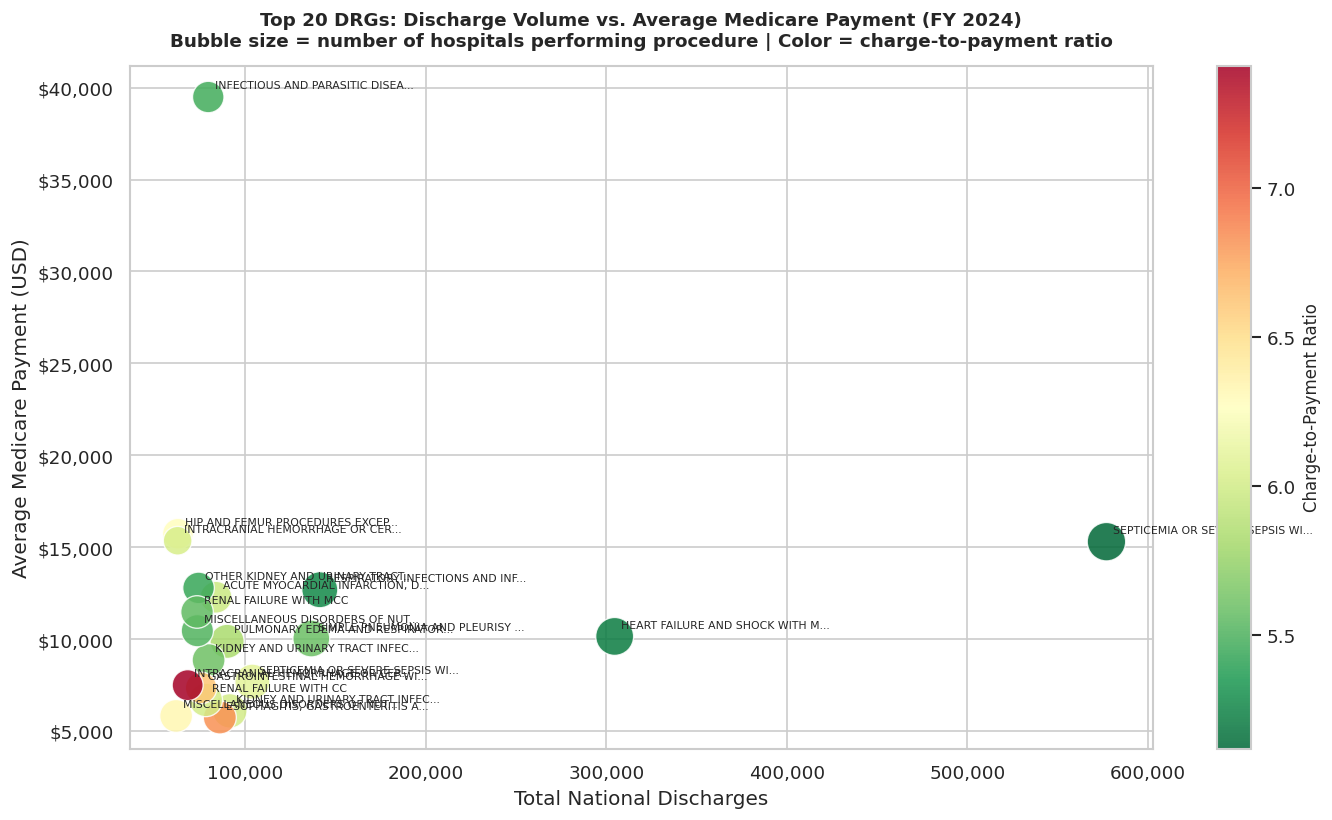

Chart 2 saved.


In [ ]:
# Chart 2: Scatter - Discharge Volume vs. Avg Medicare Payment (Top 20 DRGs)
fig, ax = plt.subplots(figsize=(12, 7))

scatter = ax.scatter(
    df_drg['Total_Discharges'],
    df_drg['Avg_Medicare_Payment'],
    s=df_drg['Hospital_Count'] / 5,
    c=df_drg['Charge_To_Payment_Ratio'],
    cmap='RdYlGn_r',
    alpha=0.85,
    edgecolors='white',
    linewidths=0.8
)

cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Charge-to-Payment Ratio', fontsize=10)

# Label each point with a shortened DRG description
for _, row in df_drg.iterrows():
    short = row['DRG_Desc'][:30] + '...' if len(row['DRG_Desc']) > 30 else row['DRG_Desc']
    ax.annotate(short, (row['Total_Discharges'], row['Avg_Medicare_Payment']),
                fontsize=6.5, ha='left', va='bottom',
                xytext=(4, 4), textcoords='offset points')

ax.set_xlabel('Total National Discharges', fontsize=12)
ax.set_ylabel('Average Medicare Payment (USD)', fontsize=12)
ax.set_title('Top 20 DRGs: Discharge Volume vs. Average Medicare Payment (FY 2024)\n'
             'Bubble size = number of hospitals performing procedure | Color = charge-to-payment ratio',
             fontsize=11, fontweight='bold', pad=12)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:,.0f}'))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'${v:,.0f}'))

plt.tight_layout()
plt.savefig('chart2_drg_scatter.png', bbox_inches='tight')
plt.show()
print('Chart 2 saved.')

---
## Section 6: Security Consideration

### Credential Management

This notebook uses google.colab.auth.authenticate_user() to authenticate with Google Cloud rather than hardcoding API keys or service account credentials directly in the code. Hardcoded credentials are a serious security mistakes in data analysis workflows. If a notebook is shared, submitted for grading, or accidentally pushed to GitHub, embedded credentials become immediately exposed to anyone who can view the file. The OAuth2 flow used here generates a temporary access token that grants BigQuery access only for the current session and expires automatically, meaning no sensitive credentials ever appear in the notebook code or output cells.

---
## Section 7: Business Insights

The following three insights are drawn directly from the exploratory analysis and visualizations above.

---

### Insight 1: There Is a Substantial and Consistent Gap Between What Hospitals Bill and What Medicare Pays

Across all states, average submitted charges are consistently and dramatically higher than average Medicare payments. This charge-to-payment ratio is not uniform. States with the highest average billed charges do not necessarily receive the highest Medicare payments, indicating that the gap is driven primarily by Chargemaster pricing strategy rather than true cost differences. For hospital finance teams, this finding reinforces the importance of focusing revenue cycle analysis on net realized payments rather than gross charges, which are a poor proxy for actual reimbursement.

---

### Insight 2: Urban Hospitals Receive Higher Average Medicare Payments Than Rural Hospitals for the Same Procedures

The groupby analysis in EDA 2 shows that urban hospitals (RUCA codes 1-3) receive measurably higher average Medicare payments per discharge than rural hospitals. This disparity reflects Medicare's geographic wage index adjustments, which are calibrated to local labor costs: costs that are structurally higher in metropolitan areas. For rural hospital administrators and policymakers, this finding highlights a systemic reimbursement gap that contributes to the financial fragility of rural health systems. It also suggests that rural hospitals face a structural disadvantage in covering fixed costs relative to their urban peers.

---

### Insight 3: High-Volume Procedures Are Not Necessarily High-Cost, and the Relationship Between Volume and Payment Is Non-Linear

The scatter plot in Section 5 shows that the top 20 DRGs by national discharge volume span a wide range of average Medicare payment levels. High-volume, common procedures (such as septicemia and heart failure) tend to cluster at moderate payment levels, while lower-volume procedures involving surgical complexity command significantly higher payments per discharge. This suggests that volume-based efficiency gains are most relevant for high-frequency medical DRGs, while surgical and procedural DRGs are where payment rate negotiation and case selection have the greatest financial impact for hospitals.